In [ ]:
# Part - 2    Supervised Machine Learning Model — Build, Train, and Evaluate

#TASK - 1
# Load cleaned dataset

import pandas as pd
df = pd.read_csv("stroke_cleaned_data.csv")

# Regression label
y_reg = df["avg_glucose_level"]

# Classification label
y_clf = df["stroke"]

#Since stroke is already a meaningful binary target, it is the best choice.
#There's no need to artificially create a binary label by splitting avg_glucose_level at its median.


# Feature matrix
X = df.drop(columns=["avg_glucose_level", "stroke"])

# check the shapes

print("Feature Matrix (X):", X.shape)
print("Regression Label (y_reg):", y_reg.shape)
print("Classification Label (y_clf):", y_clf.shape)

Feature Matrix (X): (5110, 9)
Regression Label (y_reg): (5110,)
Classification Label (y_clf): (5110,)


In [ ]:
#TASK - 2
#Encoding categorical columns

# Identify categorical columns
categorical_cols = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

# Apply One-Hot Encoding

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

#No label encoding was used because assigning integer values to these categories would create a false ordinal relationship.
#One-hot encoding represents each category as a separate binary feature, allowing machine learning models to treat the categories
#independently.
#The first dummy variable for each categorical feature was dropped (drop_first=True)
#to avoid multicollinearity (the dummy variable trap).


# Verify the encoded dataset

print("Encoded Feature Matrix Shape:", X.shape)
print("\nRemaining Data Types:")
print(X.dtypes)

print("\nFirst 5 Rows:")
print(X.head())

Encoded Feature Matrix Shape: (5110, 15)

Remaining Data Types:
age                               float64
hypertension                        int64
heart_disease                       int64
bmi                               float64
gender_Male                          bool
gender_Other                         bool
ever_married_Yes                     bool
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
Residence_type_Urban                 bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

First 5 Rows:
    age  hypertension  heart_disease   bmi  gender_Male  gender_Other  \
0  67.0             0              1  36.6         True         False   
1  61.0             0              0  28.1        False         False   
2  80.0             0              1  32.5         True   

In [ ]:
#TASK - 3
#Leak-free train-test split and scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------------------
# Train-Test Split for Regression
# ---------------------------------------
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------
# Train-Test Split for Classification
# ---------------------------------------
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------
# Feature Scaling for Regression
# ---------------------------------------
scaler_reg = StandardScaler()

X_train_reg_scaler = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaler = scaler_reg.transform(X_test_reg)

# ---------------------------------------
# Feature Scaling for Classification
# ---------------------------------------
scaler_clf = StandardScaler()

X_train_clf_scaler = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaler= scaler_clf.transform(X_test_clf)

# ---------------------------------------
# Check the shapes
# ---------------------------------------
print("Regression")
print("X_train:", X_train_reg.shape)
print("X_test :", X_test_reg.shape)
print("y_train:", y_train_reg.shape)
print("y_test :", y_test_reg.shape)

print("\nClassification")
print("X_train:", X_train_clf.shape)
print("X_test :", X_test_clf.shape)
print("y_train:", y_train_clf.shape)
print("y_test :", y_test_clf.shape)

Regression
X_train: (4088, 15)
X_test : (1022, 15)
y_train: (4088,)
y_test : (1022,)

Classification
X_train: (4088, 15)
X_test : (1022, 15)
y_train: (4088,)
y_test : (1022,)


In [ ]:
# TASK - 4
#Regression model — Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Train the model
lnr = LinearRegression()
lnr.fit(X_train_reg, y_train_reg)

# Predict on the test set
y_pred_reg = lnr.predict(X_test_reg)

# Evaluation metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Linear Regression Performance")
print(f"MSE : {mse:.4f}")
print(f"R²  : {r2:.4f}")



Linear Regression Performance
MSE : 1788.8034
R²  : 0.0697


In [ ]:
# Display coefficients

# Store feature names
feature_names = X.columns

# Create coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lnr.coef_
})

print(coef_df)

                           Feature   Coefficient
0                              age  4.271221e-01
1                     hypertension  1.757164e+01
2                    heart_disease  1.838319e+01
3                              bmi  7.149190e-01
4                      gender_Male  4.733455e+00
5                     gender_Other -1.598721e-14
6                 ever_married_Yes  1.101124e+00
7           work_type_Never_worked  8.784718e+00
8                work_type_Private  2.194478e+00
9          work_type_Self-employed  5.399170e-01
10              work_type_children  1.776995e+01
11            Residence_type_Urban -6.153737e-01
12  smoking_status_formerly smoked  3.899066e+00
13     smoking_status_never smoked  3.089295e+00
14           smoking_status_smokes  2.585038e+00


In [ ]:
#Top 3 most important coefficients
# Absolute coefficient values
coef_df["Absolute Coefficient"] = np.abs(coef_df["Coefficient"])

# Top 3 features
top3 = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
).head(3)

print("\nTop 3 Features with Largest Absolute Coefficients")
print(top3)


Top 3 Features with Largest Absolute Coefficients
               Feature  Coefficient  Absolute Coefficient
2        heart_disease    18.383185             18.383185
10  work_type_children    17.769946             17.769946
1         hypertension    17.571637             17.571637


In [ ]:
#Ridge Regression
from sklearn.linear_model import Ridge

# Train Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg_scaler, y_train_reg)

# Predictions
ridge_pred = ridge.predict(X_test_reg_scaler)

# Metrics
ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
ridge_r2 = r2_score(y_test_reg, ridge_pred)

print("\nRidge Regression Performance")
print(f"MSE : {ridge_mse:.4f}")
print(f"R²  : {ridge_r2:.4f}")


Ridge Regression Performance
MSE : 1788.7996
R²  : 0.0697


In [ ]:
#Comparison Table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

print(comparison)

#Ridge Regression performed almost identically to Linear Regression.
#Adding L2 regularization (alpha = 1.0) did not significantly improve predictive performance.

               Model          MSE  R² Score
0  Linear Regression  1788.803419  0.069711
1   Ridge Regression  1788.799610  0.069713


In [ ]:
#TASK - 5
#Classification model

#  Check class distribution
print(y_train_clf.value_counts())

# Percentage distribution
print(y_train_clf.value_counts(normalize=True) * 100)

# In dataset have highly imbalanced so we go with smote techinque method to balance the training set of data for better accuracy

#Since the minority class (4.57%) is well below the required 35%, you must address
#the imbalance before training your classification model.



stroke
0    3901
1     187
Name: count, dtype: int64
stroke
0    95.425636
1     4.574364
Name: proportion, dtype: float64


In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf_scaler, y_train_clf)

# Verify the new class distribution
print(y_train_smote.value_counts())

stroke
0    3901
1    3901
Name: count, dtype: int64


In [ ]:
# Import required libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# Train Logistic Regression on the SMOTE-resampled training data
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_smote, y_train_smote)

# Predict class labels using the SCALED test data
y_pred = log_reg.predict(X_test_clf_scaler)

# Predict probabilities (used for ROC-AUC later if needed)
y_pred_prob = log_reg.predict_proba(X_test_clf_scaler)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred)

print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test_clf, y_pred)
print("\nAccuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred))

Confusion Matrix:
[[710 250]
 [  8  54]]

Accuracy: 0.7475538160469667

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       960
           1       0.18      0.87      0.30        62

    accuracy                           0.75      1022
   macro avg       0.58      0.81      0.57      1022
weighted avg       0.94      0.75      0.81      1022



AUC Score: 0.8465137768817205


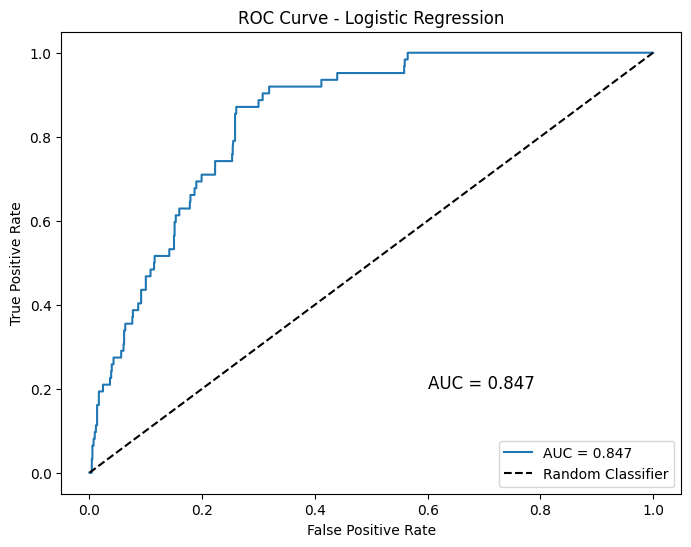

In [ ]:
#ROC AND AUC CURVE
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test_clf, y_pred_prob)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

# Annotate AUC on the plot
plt.text(0.6, 0.2, f'AUC = {auc_score:.3f}', fontsize=12)

# Save the graph
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

# Display the graph
plt.show()

In [ ]:
#Task – 6:
#Decision-Threshold Sensitivity

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

# Predict class labels on the scaled test data
y_pred = log_reg.predict(X_test_clf_scaler)

# Generate predicted probabilities
y_pred_prob = log_reg.predict_proba(X_test_clf_scaler)[:, 1]

# Display the first 10 probabilities
print(y_pred_prob[:10])

print(log_reg.predict_proba(X_test_clf_scaler))

# Decision thresholds
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    # Convert probabilities to class predictions
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_test_clf, y_pred_threshold)
    recall = recall_score(y_test_clf, y_pred_threshold)
    f1 = f1_score(y_test_clf, y_pred_threshold)

    # Store results
    results.append([threshold, precision, recall, f1])

# Display results
results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1-Score"]
)

print(results_df)

[0.03873951 0.08223581 0.03984719 0.85749687 0.76356505 0.85983544
 0.6945232  0.81870604 0.00408781 0.0226371 ]
[[0.96126049 0.03873951]
 [0.91776419 0.08223581]
 [0.96015281 0.03984719]
 ...
 [0.72870841 0.27129159]
 [0.62003427 0.37996573]
 [0.13078285 0.86921715]]
   Threshold  Precision    Recall  F1-Score
0        0.3   0.128959  0.919355  0.226190
1        0.4   0.152815  0.919355  0.262069
2        0.5   0.177632  0.870968  0.295082
3        0.6   0.186147  0.693548  0.293515
4        0.7   0.195266  0.532258  0.285714


In [ ]:
#TASK - 7
#Regularization experiment on Logistic Regression:

#Train Logistic Regression with C = 0.01

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score
)

# Strongly regularized Logistic Regression
log_reg_c001 = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_c001.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_c001 = log_reg_c001.predict(X_test_clf_scaler)
y_prob_c001 = log_reg_c001.predict_proba(X_test_clf_scaler)[:, 1]

# Metrics
precision_c001 = precision_score(y_test_clf, y_pred_c001)
recall_c001 = recall_score(y_test_clf, y_pred_c001)
auc_c001 = roc_auc_score(y_test_clf, y_prob_c001)

print("Precision:", precision_c001)
print("Recall:", recall_c001)
print("AUC:", auc_c001)

Precision: 0.17252396166134185
Recall: 0.8709677419354839
AUC: 0.8502604166666666


In [ ]:
# Baseline model (default C=1.0)
y_prob_baseline = log_reg.predict_proba(X_test_clf_scaler)[:, 1]

# Strongly regularized model (C=0.01)
y_prob_c001 = log_reg_c001.predict_proba(X_test_clf_scaler)[:, 1]



In [ ]:
#Task - 8
# Bootstrap confidence interval for AUC difference
import numpy as np
from sklearn.metrics import roc_auc_score

np.random.seed(42)

n_bootstrap = 500
auc_differences = []

for i in range(n_bootstrap):

    # Sample row indices with replacement
    indices = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    # Bootstrap sample
    y_true_boot = y_test_clf.iloc[indices]

    prob_baseline_boot = y_prob_baseline[indices]
    prob_c001_boot = y_prob_c001[indices]

    # Skip if only one class is present
    if len(np.unique(y_true_boot)) < 2:
        continue

    # Compute AUCs
    auc_baseline = roc_auc_score(y_true_boot, prob_baseline_boot)
    auc_c001 = roc_auc_score(y_true_boot, prob_c001_boot)

    # Difference = C=1.0 - C=0.01
    auc_differences.append(auc_baseline - auc_c001)

# Mean difference
mean_diff = np.mean(auc_differences)

# 95% Confidence Interval
lower = np.percentile(auc_differences, 2.5)
upper = np.percentile(auc_differences, 97.5)

print("Mean AUC Difference:", mean_diff)
print("95% Confidence Interval:")
print("Lower:", lower)
print("Upper:", upper)

Mean AUC Difference: -0.003849379285161346
95% Confidence Interval:
Lower: -0.008335970529979775
Upper: 0.0003854889834620031
